# Traffix.id — Final LSTM Optimization for Multi-Horizon Traffic Forecasting

**Project Code:** PJK-GM047  
**Dataset:** `traffix_lstm_ready.csv`  
**Feature Registry:** `feature_columns.json`

---

## Modeling Strategy

This notebook implements the final LSTM optimization pipeline for the Traffix.id traffic forecasting system. The primary forecasting target is the **15-minute horizon**, which supports short-term traffic density prediction at urban intersections in Indonesia.

**Scope of this notebook:**
- The dataset (`traffix_lstm_ready.csv`) is feature-ready. All preprocessing and feature engineering have been handled by the Data Division.
- This notebook focuses exclusively on **modeling, evaluation, and artifact export**.
- The test set is locked and is not used for any tuning or model selection decisions.
- The validation set is used solely to select the best hyperparameter configuration.
- The 15-minute horizon is the primary focus; 2-hour and 4-hour models are trained using the same optimized configuration.

**Modeling approach:**
- Independent LSTM model per forecast horizon (15-minute, 2-hour, 4-hour)
- Controlled hyperparameter optimization via grid search for the 15-minute model
- Loss functions evaluated: MAE, Huber, MAPE-safe
- Architectures evaluated: Lightweight LSTM, Bidirectional LSTM (BiLSTM)
- Comprehensive evaluation metrics: MAE, MSE, RMSE, MAPE, SMAPE, R², Accuracy-Like, Within-15%
- Baseline comparison: Persistence, Linear Regression, XGBoost, LSTM (prior baseline)
- Artifact export: trained models, scalers, configuration, metrics, comparison table, training history, ZIP archive


## 1. Import Libraries


In [5]:
import os, json, zipfile, warnings, itertools, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('[INFO] XGBoost not available. Install with: pip install xgboost')

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print('Environment summary:')
print(f'  TensorFlow : {tf.__version__}')
print(f'  NumPy      : {np.__version__}')
print(f'  Pandas     : {pd.__version__}')
print(f'  XGBoost    : {"Available" if XGBOOST_AVAILABLE else "Not installed"}')

Environment summary:
  TensorFlow : 2.20.0
  NumPy      : 2.0.2
  Pandas     : 2.2.2
  XGBoost    : Available


## 2. Runtime Configuration


In [6]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU detected: {len(gpus)} device(s)')
else:
    print('No GPU detected. Training on CPU.')
    print('Note: GPU acceleration is recommended. Enable via Runtime > Change runtime type > T4 GPU.')

GPU detected: 1 device(s)


## 3. Configuration


In [7]:
# File paths
CSV_PATH          = 'traffix_lstm_ready.csv'
FEATURE_JSON_PATH = 'feature_columns.json'
ARTIFACTS_DIR     = 'artifacts'
ZIP_PATH          = 'traffix_lstm_optimized_artifacts.zip'

# Target columns
TARGET_COLS    = ['target_volume_15m', 'target_volume_2h', 'target_volume_4h']
HORIZON_LABELS = ['15m', '2h', '4h']
HORIZON_IDX    = {h: i for i, h in enumerate(HORIZON_LABELS)}

# Time split ratios
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
# Test = remaining 15% — locked; not used for tuning

# Default training config
MAX_EPOCHS  = 100

# Hyperparameter search space (15-minute model)
GRID_SEQ_LEN      = [15, 30, 60, 120]
GRID_SCALER       = ['standard', 'robust', 'minmax']
GRID_LR           = [1e-3, 5e-4, 1e-4]
GRID_BATCH        = [32, 64]
GRID_DROPOUT      = [0.1, 0.2]
GRID_LOSS         = ['mae', 'huber', 'mape_safe']
GRID_ARCH         = ['lstm_light', 'bilstm']

# QUICK_GRID = True  : evaluates a representative subset of configurations (recommended for standard runs)
# QUICK_GRID = False : evaluates the full Cartesian product of the search space (extended runtime)
QUICK_GRID = True

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
print('Configuration loaded.')
print(f'  Artifacts dir : {ARTIFACTS_DIR}/')
print(f'  Grid mode     : {"Representative subset" if QUICK_GRID else "Full grid"}')

Configuration loaded.
  Artifacts dir : artifacts/
  Grid mode     : Representative subset


## 4. Load Dataset


In [8]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
df.head(3)

Dataset loaded: 9,780 rows x 52 columns
Memory: 7.18 MB


,tick,timestamp_wib,intersectionId,vehicle_count_1min,volume_veh_per_hour,avg_speed_kmh,queue_length_veh,wait_time_min,green_seconds,density_percent,...,roll_max_60,delta_volume,weather_condition_Clear,weather_condition_Cloudy,weather_condition_Hot,weather_condition_Rain,target_volume_15m,target_volume_2h,target_volume_4h,weather_condition
0,60,2026-05-01 01:00:00+07:00,TMG-1012,40,2423.33,55.9275,0,0.0,24.50,0.0550,...,2904.34,501.84,1,0,0,0,1814.60,1419.41,2034.38,Clear
1,61,2026-05-01 01:01:00+07:00,TMG-1012,35,2162.67,56.7650,0,0.0,24.00,0.1750,...,2904.34,-260.66,1,0,0,0,1631.04,1258.10,1150.77,Clear
2,62,2026-05-01 01:02:00+07:00,TMG-1012,17,1016.72,57.0200,0,0.0,23.75,0.2825,...,2904.34,-1145.95,1,0,0,0,1920.82,2058.73,1379.26,Clear


## 5. Dataset Validation

Basic integrity checks are applied prior to modeling. The dataset is expected to be fully preprocessed and free of missing values.


In [9]:
print('Running dataset validation...')
assert df.shape[0] > 0, 'Dataset is empty.'
print(f'  [OK] Non-empty: {df.shape[0]:,} rows')

total_nulls = df.isnull().sum().sum()
assert total_nulls == 0, f'Dataset memiliki {total_nulls} missing values.'
print(f'  [OK] No missing values detected')

for col in TARGET_COLS:
    assert col in df.columns, f'Expected target column not found: {col}'
print(f'  [OK] All target columns present')

print('Dataset validation completed.')
print('\nTarget column distribution:')
print(df[TARGET_COLS].describe().round(2))

Running dataset validation...
  [OK] Non-empty: 9,780 rows
  [OK] No missing values detected
  [OK] All target columns present
Dataset validation completed.

Target column distribution:
       target_volume_15m  target_volume_2h  target_volume_4h
count            9780.00           9780.00           9780.00
mean             2234.71           2235.89           2240.71
std              1266.66           1266.20           1264.57
min               486.63            486.63            486.63
25%              1405.58           1406.04           1412.02
50%              1843.97           1848.84           1857.24
75%              2579.30           2580.36           2584.66
max             10344.70          10344.70          10344.70


## 6. Load Feature Columns

Feature columns are loaded from the registry file produced by the Data Division. No feature engineering is performed in this notebook.


In [10]:
with open(FEATURE_JSON_PATH, 'r') as f:
    FEATURE_COLS = json.load(f)

missing_cols = [c for c in FEATURE_COLS if c not in df.columns]
assert len(missing_cols) == 0, f'Feature columns not found in dataset: {missing_cols}'

NUM_FEATURES = len(FEATURE_COLS)
print(f'Feature registry loaded: {NUM_FEATURES} features')
for i, col in enumerate(FEATURE_COLS):
    print(f'  [{i:02d}] {col}')

Feature registry loaded: 41 features
  [00] vehicle_count_1min
  [01] volume_veh_per_hour
  [02] avg_speed_kmh
  [03] queue_length_veh
  [04] wait_time_min
  [05] green_seconds
  [06] density_percent
  [07] weather_temp_c
  [08] accident_count
  [09] roadwork_flag
  [10] event_flag
  [11] hour
  [12] minute
  [13] day
  [14] day_of_week
  [15] month
  [16] is_holiday
  [17] is_weekend
  [18] hour_sin
  [19] hour_cos
  [20] delta_volume
  [21] lag_1
  [22] lag_5
  [23] lag_15
  [24] lag_30
  [25] lag_60
  [26] lag_speed_15
  [27] lag_queue_15
  [28] roll_mean_15
  [29] roll_std_15
  [30] roll_min_15
  [31] roll_max_15
  [32] roll_median_15
  [33] roll_mean_60
  [34] roll_std_60
  [35] roll_min_60
  [36] roll_max_60
  [37] weather_condition_Clear
  [38] weather_condition_Cloudy
  [39] weather_condition_Hot
  [40] weather_condition_Rain


## 7. Prepare Model DataFrame


In [11]:
df_model = df[FEATURE_COLS + TARGET_COLS].copy().reset_index(drop=True)
print(f'Model dataframe: {df_model.shape}')
print(f'  Features: {NUM_FEATURES}, Targets: {len(TARGET_COLS)}')
print(f'  Missing values: {df_model.isnull().sum().sum()}')

Model dataframe: (9780, 44)
  Features: 41, Targets: 3
  Missing values: 0


## 8. Temporal Train / Validation / Test Split

**Data integrity:** The split is strictly time-ordered. No shuffling is applied. The test set is locked and isolated from all model selection and tuning decisions.


In [12]:
n = len(df_model)
n_train = int(n * TRAIN_RATIO)
n_val   = int(n * VAL_RATIO)
n_test  = n - n_train - n_val

df_train = df_model.iloc[:n_train].reset_index(drop=True)
df_val   = df_model.iloc[n_train : n_train + n_val].reset_index(drop=True)
df_test  = df_model.iloc[n_train + n_val :].reset_index(drop=True)

print('Temporal split completed.')
print('  Split configuration (no shuffling, no leakage):')
print(f'  Total      : {n:,}')
print(f'  Train      : {len(df_train):>6,} ({100*len(df_train)/n:.1f}%)')
print(f'  Validation : {len(df_val):>6,} ({100*len(df_val)/n:.1f}%)')
print(f'  Test       : {len(df_test):>6,} ({100*len(df_test)/n:.1f}%)')

Temporal split completed.
  Split configuration (no shuffling, no leakage):
  Total      : 9,780
  Train      :  6,846 (70.0%)
  Validation :  1,467 (15.0%)
  Test       :  1,467 (15.0%)


## 9. Helper Functions


In [13]:
# Scaler factory
def get_scaler(name: str):
    """Instantiate a scaler by name. Caller is responsible for fitting."""
    mapping = {
        'standard': StandardScaler(),
        'robust':   RobustScaler(),
        'minmax':   MinMaxScaler(),
    }
    if name not in mapping:
        raise ValueError(f'Unknown scaler: {name}. Options: {list(mapping)}')
    return mapping[name]


# Sequence builder
def build_sequences(X: np.ndarray, y: np.ndarray, seq_len: int):
    """
    Build overlapping sliding window sequences.
    X: (T, F), y: (T,) or (T, targets)
    Returns xs: (T-seq_len, seq_len, F), ys: (T-seq_len, ...)
    """
    xs, ys = [], []
    for i in range(seq_len, len(X)):
        xs.append(X[i - seq_len : i])
        ys.append(y[i])
    return np.array(xs, dtype=np.float32), np.array(ys, dtype=np.float32)


# Metrics
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, label: str = '') -> dict:
    """
    Compute comprehensive regression metrics in original scale.
    """
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()

    mae   = mean_absolute_error(y_true, y_pred)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_true, y_pred)

    # MAPE — skip zeros to avoid div/0
    mask  = y_true != 0
    mape  = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    # SMAPE
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_vals = np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom) * 100
    smape = np.mean(smape_vals)

    acc_like    = max(0.0, 100 - mape)
    within_15pct = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) <= 0.15) * 100

    m = {
        'label'       : label,
        'MAE'         : round(float(mae), 4),
        'MSE'         : round(float(mse), 4),
        'RMSE'        : round(float(rmse), 4),
        'MAPE'        : round(float(mape), 4),
        'SMAPE'       : round(float(smape), 4),
        'R2'          : round(float(r2), 4),
        'Acc_Like'    : round(float(acc_like), 4),
        'Within_15pct': round(float(within_15pct), 4),
    }
    return m

def print_metrics(m: dict):
    print(f"  MAE          : {m['MAE']:.2f}")
    print(f"  RMSE         : {m['RMSE']:.2f}")
    print(f"  MAPE         : {m['MAPE']:.3f}%")
    print(f"  SMAPE        : {m['SMAPE']:.3f}%")
    print(f"  R²           : {m['R2']:.4f}")
    print(f"  Acc-Like     : {m['Acc_Like']:.2f}%")
    print(f"  Within 15%   : {m['Within_15pct']:.2f}%")

print('Utility functions loaded.')

Utility functions loaded.


## 10. LSTM Architecture Builders


In [14]:
# Custom MAPE-safe loss
def mape_safe_loss(epsilon: float = 1.0):
    """MAPE-like loss with epsilon guard to prevent div/0 on near-zero targets."""
    def loss(y_true, y_pred):
        diff = tf.abs(y_true - y_pred)
        denom = tf.abs(y_true) + epsilon
        return tf.reduce_mean(diff / denom) * 100.0
    return loss


def get_loss_fn(name: str):
    """Return compiled loss by name."""
    if name == 'mae':
        return 'mae'
    elif name == 'huber':
        return keras.losses.Huber(delta=1.0)
    elif name == 'mape_safe':
        return mape_safe_loss(epsilon=1.0)
    else:
        raise ValueError(f'Unknown loss: {name}')


# Lightweight LSTM
def build_lstm_light(num_features, seq_len, learning_rate, dropout, loss_name):
    """
    Lightweight LSTM: LSTM(64, return_sequences=True) -> Dropout -> LSTM(32) -> Dense(64, ReLU) -> Dense(1).
    """
    inp = keras.Input(shape=(seq_len, num_features), name='input')
    x = layers.LSTM(64, return_sequences=True, name='lstm1')(inp)
    x = layers.Dropout(dropout, name='drop1')(x)
    x = layers.LSTM(32, return_sequences=False, name='lstm2')(x)
    x = layers.Dense(64, activation='relu', name='dense1')(x)
    x = layers.Dropout(dropout / 2, name='drop2')(x)
    out = layers.Dense(1, activation='linear', name='output')(x)

    model = keras.Model(inp, out, name='lstm_light')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=get_loss_fn(loss_name),
        metrics=['mae']
    )
    return model

# BiLSTM
def build_bilstm(num_features, seq_len, learning_rate, dropout, loss_name):
    """
    BiLSTM: Bidirectional LSTM(64, return_sequences=True) -> Dropout -> LSTM(32) -> Dense(64, ReLU) -> Dense(1).
    """
    inp = keras.Input(shape=(seq_len, num_features), name='input')
    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=True), name='bilstm1'
    )(inp)
    x = layers.Dropout(dropout, name='drop1')(x)
    x = layers.LSTM(32, return_sequences=False, name='lstm2')(x)
    x = layers.Dense(64, activation='relu', name='dense1')(x)
    x = layers.Dropout(dropout / 2, name='drop2')(x)
    out = layers.Dense(1, activation='linear', name='output')(x)

    model = keras.Model(inp, out, name='bilstm')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=get_loss_fn(loss_name),
        metrics=['mae']
    )
    return model

def build_model(arch, num_features, seq_len, lr, dropout, loss_name):
    if arch == 'lstm_light':
        return build_lstm_light(num_features, seq_len, lr, dropout, loss_name)
    elif arch == 'bilstm':
        return build_bilstm(num_features, seq_len, lr, dropout, loss_name)
    else:
        raise ValueError(f'Unknown arch: {arch}')

print('Architecture builders loaded.')

Architecture builders loaded.


## 11. Feature Scaling

The feature scaler is fitted exclusively on the training set and applied to validation and test sets. This ensures no data leakage from future observations.


In [15]:
# Feature scaler: StandardScaler fitted on training data only.
# Target scalers are fitted per horizon inside the grid search loop.
feat_scaler = StandardScaler()
X_train_sc = feat_scaler.fit_transform(df_train[FEATURE_COLS].values)
X_val_sc   = feat_scaler.transform(df_val[FEATURE_COLS].values)
X_test_sc  = feat_scaler.transform(df_test[FEATURE_COLS].values)

assert not np.isnan(X_train_sc).any()
assert not np.isnan(X_val_sc).any()
assert not np.isnan(X_test_sc).any()

print('Feature scaler fitted on training data only.')
print(f'  X_train_sc shape: {X_train_sc.shape}')
print(f'  X_val_sc   shape: {X_val_sc.shape}')
print(f'  X_test_sc  shape: {X_test_sc.shape}')

Feature scaler fitted on training data only.
  X_train_sc shape: (6846, 41)
  X_val_sc   shape: (1467, 41)
  X_test_sc  shape: (1467, 41)


## 12. Hyperparameter Optimization — 15-Minute Model

Grid search is used as a controlled hyperparameter optimization procedure. Each configuration is trained independently, evaluated on the validation set (MAPE in original scale), and compared systematically. The test set is not accessed at any point during this phase.

The search space covers: sequence length, target scaler type, learning rate, batch size, dropout rate, loss function, and model architecture. When `QUICK_GRID = True`, a representative subset of configurations is evaluated; setting `QUICK_GRID = False` evaluates the full Cartesian product.


In [16]:
TARGET_15M = 'target_volume_15m'

# Raw (unscaled) target values per split
y_train_raw_15m = df_train[TARGET_15M].values
y_val_raw_15m   = df_val[TARGET_15M].values
y_test_raw_15m  = df_test[TARGET_15M].values

# Grid configuration
if QUICK_GRID:
    # Representative subset covering major axes of variation
    GRID_CONFIGS = [
        # (seq_len, scaler, lr, batch, dropout, loss, arch)
        (60,  'standard', 1e-3, 32, 0.1, 'mae',       'lstm_light'),
        (60,  'standard', 5e-4, 32, 0.1, 'mae',       'lstm_light'),
        (30,  'robust',   1e-3, 32, 0.1, 'mae',       'lstm_light'),
        (30,  'robust',   5e-4, 64, 0.2, 'mae',       'lstm_light'),
        (15,  'standard', 1e-3, 32, 0.1, 'mae',       'lstm_light'),
        (60,  'standard', 1e-3, 32, 0.1, 'huber',     'lstm_light'),
        (60,  'robust',   5e-4, 32, 0.1, 'mape_safe', 'lstm_light'),
        (60,  'standard', 1e-3, 32, 0.1, 'mae',       'bilstm'),
        (30,  'robust',   5e-4, 32, 0.1, 'mae',       'bilstm'),
        (120, 'standard', 1e-3, 32, 0.1, 'mae',       'lstm_light'),
        (60,  'minmax',   1e-3, 32, 0.1, 'mae',       'lstm_light'),
        (30,  'standard', 1e-4, 32, 0.1, 'mae',       'lstm_light'),
    ]
else:
    # Full Cartesian product — significantly longer runtime
    GRID_CONFIGS = list(itertools.product(
        GRID_SEQ_LEN, GRID_SCALER, GRID_LR, GRID_BATCH, GRID_DROPOUT, GRID_LOSS, GRID_ARCH
    ))

print(f'Grid search initialized: {len(GRID_CONFIGS)} configurations to evaluate.')
print('Parameters: (seq_len, scaler, lr, batch, dropout, loss, arch)')

Grid search initialized: 12 configurations to evaluate.
Parameters: (seq_len, scaler, lr, batch, dropout, loss, arch)


In [17]:
grid_results = []
best_val_mape_15m = float('inf')
best_cfg_15m = None
best_model_15m = None
best_tgt_scaler_15m = None
best_history_15m = None

tmp_model_path = os.path.join(ARTIFACTS_DIR, '_tmp_best.keras')

for cfg_idx, cfg in enumerate(GRID_CONFIGS):
    seq_len, scaler_name, lr, batch_size, dropout, loss_name, arch = cfg

    cfg_label = f'cfg{cfg_idx:02d}|seq{seq_len}|{scaler_name}|lr{lr}|bs{batch_size}|do{dropout}|{loss_name}|{arch}'
    print(f'\n[{cfg_idx+1}/{len(GRID_CONFIGS)}] {cfg_label}')

    # Target scaler — fit on train only
    tgt_sc = get_scaler(scaler_name)
    y_train_sc = tgt_sc.fit_transform(y_train_raw_15m.reshape(-1, 1)).ravel()
    y_val_sc   = tgt_sc.transform(y_val_raw_15m.reshape(-1, 1)).ravel()
    # y_test is not scaled here; evaluation is performed in original scale

    # Sequence construction
    try:
        X_tr, y_tr = build_sequences(X_train_sc, y_train_sc, seq_len)
        X_vl, y_vl = build_sequences(X_val_sc,   y_val_sc,   seq_len)
    except Exception as e:
        print(f'  [SKIP] Sequence build failed: {e}')
        continue

    if len(X_tr) < 10 or len(X_vl) < 5:
        print(f'  [SKIP] Not enough sequences (train={len(X_tr)}, val={len(X_vl)})')
        continue

    # Build model
    try:
        model = build_model(arch, NUM_FEATURES, seq_len, lr, dropout, loss_name)
    except Exception as e:
        print(f'  [SKIP] Model build failed: {e}')
        continue

    # Callbacks
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=12, restore_best_weights=True, verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=0
        ),
        keras.callbacks.ModelCheckpoint(
            tmp_model_path, monitor='val_loss', save_best_only=True, verbose=0
        ),
    ]

    # Training
    t0 = time.time()
    try:
        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_vl, y_vl),
            epochs=MAX_EPOCHS,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=0
        )
    except Exception as e:
        print(f'  [SKIP] Training failed: {e}')
        continue
    elapsed = time.time() - t0

    # Validation MAPE in original scale
    y_vl_pred_sc = model.predict(X_vl, verbose=0).ravel()
    y_vl_pred    = tgt_sc.inverse_transform(y_vl_pred_sc.reshape(-1, 1)).ravel()
    y_vl_true    = y_val_raw_15m[seq_len:]  # align with sequence offset

    # Guard length mismatch
    min_len = min(len(y_vl_pred), len(y_vl_true))
    y_vl_pred = y_vl_pred[:min_len]
    y_vl_true = y_vl_true[:min_len]

    mask = y_vl_true != 0
    val_mape = np.mean(np.abs((y_vl_true[mask] - y_vl_pred[mask]) / y_vl_true[mask])) * 100
    val_mae  = mean_absolute_error(y_vl_true, y_vl_pred)

    epochs_ran = len(history.history['loss'])
    print(f'  Epochs: {epochs_ran} | Val MAPE: {val_mape:.3f}% | Val MAE: {val_mae:.2f} | Time: {elapsed:.0f}s')

    grid_results.append({
        'cfg_idx'   : cfg_idx,
        'cfg_label' : cfg_label,
        'seq_len'   : seq_len,
        'scaler'    : scaler_name,
        'lr'        : lr,
        'batch_size': batch_size,
        'dropout'   : dropout,
        'loss'      : loss_name,
        'arch'      : arch,
        'val_mape'  : round(val_mape, 4),
        'val_mae'   : round(val_mae, 4),
        'epochs'    : epochs_ran,
        'time_s'    : round(elapsed, 1),
    })

    # Update best
    if val_mape < best_val_mape_15m:
        best_val_mape_15m  = val_mape
        best_cfg_15m       = cfg
        best_model_15m     = model
        best_tgt_scaler_15m = tgt_sc
        best_history_15m   = history
        print(f'  *** NEW BEST Val MAPE: {val_mape:.3f}% ***')

print('\n' + '='*60)
print(f'Hyperparameter optimization completed. {len(grid_results)} configurations evaluated.')
if best_cfg_15m:
    seq_len, scaler_name, lr, batch_size, dropout, loss_name, arch = best_cfg_15m
    print(f'Best configuration (15-minute horizon):')
    print(f'  seq_len={seq_len}, scaler={scaler_name}, lr={lr}, batch={batch_size}')
    print(f'  dropout={dropout}, loss={loss_name}, arch={arch}')
    print(f'  Val MAPE = {best_val_mape_15m:.3f}%')


[1/12] cfg00|seq60|standard|lr0.001|bs32|do0.1|mae|lstm_light
  Epochs: 19 | Val MAPE: 21.608% | Val MAE: 507.51 | Time: 55s
  *** NEW BEST Val MAPE: 21.608% ***

[2/12] cfg01|seq60|standard|lr0.0005|bs32|do0.1|mae|lstm_light
  Epochs: 18 | Val MAPE: 21.856% | Val MAE: 508.67 | Time: 48s

[3/12] cfg02|seq30|robust|lr0.001|bs32|do0.1|mae|lstm_light
  Epochs: 25 | Val MAPE: 21.772% | Val MAE: 510.87 | Time: 49s

[4/12] cfg03|seq30|robust|lr0.0005|bs64|do0.2|mae|lstm_light
  Epochs: 38 | Val MAPE: 21.604% | Val MAE: 503.29 | Time: 43s
  *** NEW BEST Val MAPE: 21.604% ***

[5/12] cfg04|seq15|standard|lr0.001|bs32|do0.1|mae|lstm_light
  Epochs: 28 | Val MAPE: 21.460% | Val MAE: 508.41 | Time: 54s
  *** NEW BEST Val MAPE: 21.460% ***

[6/12] cfg05|seq60|standard|lr0.001|bs32|do0.1|huber|lstm_light
  Epochs: 14 | Val MAPE: 20.343% | Val MAE: 498.88 | Time: 35s
  *** NEW BEST Val MAPE: 20.343% ***

[7/12] cfg06|seq60|robust|lr0.0005|bs32|do0.1|mape_safe|lstm_light
  Epochs: 24 | Val MAPE: 19.

In [18]:
# Tampilkan grid search results
df_grid = pd.DataFrame(grid_results).sort_values('val_mape')
print('Top 10 configurations by validation MAPE (15-minute horizon):')
print(df_grid[['cfg_label', 'val_mape', 'val_mae', 'epochs']].head(10).to_string(index=False))

Top 10 configurations by validation MAPE (15-minute horizon):
                                                  cfg_label  val_mape  val_mae  epochs
cfg06|seq60|robust|lr0.0005|bs32|do0.1|mape_safe|lstm_light   19.9826 504.4138      24
          cfg08|seq30|robust|lr0.0005|bs32|do0.1|mae|bilstm   20.2063 476.8095      20
   cfg05|seq60|standard|lr0.001|bs32|do0.1|huber|lstm_light   20.3426 498.8821      14
       cfg10|seq60|minmax|lr0.001|bs32|do0.1|mae|lstm_light   20.3841 485.5200      20
    cfg09|seq120|standard|lr0.001|bs32|do0.1|mae|lstm_light   21.2252 522.9828      32
         cfg07|seq60|standard|lr0.001|bs32|do0.1|mae|bilstm   21.4110 519.8587      15
     cfg04|seq15|standard|lr0.001|bs32|do0.1|mae|lstm_light   21.4595 508.4066      28
      cfg03|seq30|robust|lr0.0005|bs64|do0.2|mae|lstm_light   21.6042 503.2861      38
     cfg00|seq60|standard|lr0.001|bs32|do0.1|mae|lstm_light   21.6080 507.5064      19
       cfg02|seq30|robust|lr0.001|bs32|do0.1|mae|lstm_light   21.772

## 13. Final Evaluation — 15-Minute Model on Test Set

The best configuration selected by grid search is evaluated on the locked test set. This is the only point at which test data is accessed for the 15-minute model.


In [20]:
assert best_model_15m is not None, 'No 15-minute model selected. Verify grid search completed successfully.'

best_seq_len_15m = best_cfg_15m[0]

# Construct test sequences using the optimal sequence length
X_test_seq_15m, _ = build_sequences(
    X_test_sc,
    y_test_raw_15m,  # placeholder — not used for scaling
    best_seq_len_15m
)
y_test_true_15m = y_test_raw_15m[best_seq_len_15m:]

# Predict
y_test_pred_sc_15m = best_model_15m.predict(X_test_seq_15m, verbose=0).ravel()
y_test_pred_15m    = best_tgt_scaler_15m.inverse_transform(
    y_test_pred_sc_15m.reshape(-1, 1)
).ravel()

# Align prediction and ground truth lengths
min_len = min(len(y_test_pred_15m), len(y_test_true_15m))
y_test_pred_15m = y_test_pred_15m[:min_len]
y_test_true_15m = y_test_true_15m[:min_len]

metrics_15m_opt = compute_metrics(y_test_true_15m, y_test_pred_15m, 'LSTM_Optimized_15m')

print('Test Set Evaluation — LSTM Optimized (15-minute horizon)')
print('-' * 50)
print_metrics(metrics_15m_opt)

Test Set Evaluation — LSTM Optimized (15-minute horizon)
--------------------------------------------------
  MAE          : 506.56
  RMSE         : 700.71
  MAPE         : 20.605%
  SMAPE        : 20.581%
  R²           : 0.6712
  Acc-Like     : 79.40%
  Within 15%   : 43.50%


## 14. Training Models for 2-Hour and 4-Hour Horizons

The 2-hour and 4-hour forecast models are trained using the optimal configuration identified during the 15-minute grid search. Target scalers are re-fitted independently for each horizon.


In [21]:
def train_horizon_model(target_col: str, horizon_label: str, best_cfg):
    """
    Train a single LSTM model for the specified forecast horizon using the optimal configuration
    from the 15-minute grid search. The target scaler is re-fitted on the training data
    for each horizon independently to prevent data leakage.
    """
    seq_len, scaler_name, lr, batch_size, dropout, loss_name, arch = best_cfg

    print(f'\nTraining LSTM — {horizon_label} horizon')
    print('-' * 40)
    print(f'    target: {target_col}')
    print(f'    arch={arch}, seq_len={seq_len}, scaler={scaler_name}, lr={lr}')
    print(f'    batch={batch_size}, dropout={dropout}, loss={loss_name}')

    y_train_r = df_train[target_col].values
    y_val_r   = df_val[target_col].values
    y_test_r  = df_test[target_col].values

    # Target scaler: fit on training data only
    tgt_sc = get_scaler(scaler_name)
    y_tr_sc = tgt_sc.fit_transform(y_train_r.reshape(-1, 1)).ravel()
    y_vl_sc = tgt_sc.transform(y_val_r.reshape(-1, 1)).ravel()

    # Sequences
    X_tr, y_tr = build_sequences(X_train_sc, y_tr_sc, seq_len)
    X_vl, y_vl = build_sequences(X_val_sc,   y_vl_sc, seq_len)
    X_te, _    = build_sequences(X_test_sc,  y_test_r, seq_len)
    y_te_true  = y_test_r[seq_len:]

    # Build & train
    model = build_model(arch, NUM_FEATURES, seq_len, lr, dropout, loss_name)

    model_path = os.path.join(ARTIFACTS_DIR, f'best_lstm_{horizon_label}.keras')
    callbacks_h = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=12, restore_best_weights=True, verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=0
        ),
        keras.callbacks.ModelCheckpoint(
            model_path, monitor='val_loss', save_best_only=True, verbose=0
        ),
    ]

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_vl, y_vl),
        epochs=MAX_EPOCHS,
        batch_size=batch_size,
        callbacks=callbacks_h,
        verbose=0
    )
    print(f'    Training completed. Epochs: {len(history.history["loss"])}')

    # Test evaluation
    y_te_pred_sc = model.predict(X_te, verbose=0).ravel()
    y_te_pred    = tgt_sc.inverse_transform(y_te_pred_sc.reshape(-1, 1)).ravel()
    min_l = min(len(y_te_pred), len(y_te_true))
    metrics = compute_metrics(y_te_true[:min_l], y_te_pred[:min_l], f'LSTM_Opt_{horizon_label}')

    print(f'    Test MAPE: {metrics["MAPE"]:.3f}%    R2: {metrics["R2"]:.4f}')

    return model, tgt_sc, history, metrics, y_te_true[:min_l], y_te_pred[:min_l]

# Train 2h
model_2h, tgt_sc_2h, hist_2h, metrics_2h_opt, y_test_true_2h, y_test_pred_2h = \
    train_horizon_model('target_volume_2h', '2h', best_cfg_15m)

# Train 4h
model_4h, tgt_sc_4h, hist_4h, metrics_4h_opt, y_test_true_4h, y_test_pred_4h = \
    train_horizon_model('target_volume_4h', '4h', best_cfg_15m)


Training LSTM — 2h horizon
----------------------------------------
    target: target_volume_2h
    arch=lstm_light, seq_len=60, scaler=robust, lr=0.0005
    batch=32, dropout=0.1, loss=mape_safe
    Training completed. Epochs: 24
    Test MAPE: 26.953%    R2: 0.1952

Training LSTM — 4h horizon
----------------------------------------
    target: target_volume_4h
    arch=lstm_light, seq_len=60, scaler=robust, lr=0.0005
    batch=32, dropout=0.1, loss=mape_safe
    Training completed. Epochs: 44
    Test MAPE: 25.837%    R2: 0.3489


## 15. Baseline Models

Three baseline models are evaluated on the same test set and aligned index as the LSTM models: Persistence (last-value carry-forward), Linear Regression, and XGBoost. A prior LSTM result is included as a reference metric from previous modeling work.


In [22]:
# Align baseline predictions to the same index offset as LSTM sequences
best_seq = best_cfg_15m[0]

# Persistence Baseline
# Prediction: carry forward the last observed value
y_test_lag1 = X_test_sc[best_seq:, FEATURE_COLS.index('lag_1')] \
    if 'lag_1' in FEATURE_COLS else None

# Use lagged target value (t-1) from raw data as persistence prediction
y_test_persist = df_test[TARGET_COLS[0]].shift(1).fillna(method='bfill').values[best_seq:]
y_true_align   = y_test_raw_15m[best_seq:]
min_len_b      = min(len(y_test_persist), len(y_true_align))
metrics_persist = compute_metrics(y_true_align[:min_len_b], y_test_persist[:min_len_b], 'Persistence')
print(f'  Persistence        MAPE: {metrics_persist["MAPE"]:.3f}%')

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(df_train[FEATURE_COLS].values, df_train[TARGET_COLS[0]].values)
y_linreg_pred = lr_model.predict(df_test[FEATURE_COLS].values)[best_seq:]
metrics_linreg = compute_metrics(y_true_align[:min(len(y_linreg_pred), len(y_true_align))],
                                  y_linreg_pred[:min(len(y_linreg_pred), len(y_true_align))],
                                  'LinearRegression')
print(f'  Linear Regression  MAPE: {metrics_linreg["MAPE"]:.3f}%')

# XGBoost
if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0
    )
    xgb_model.fit(
        df_train[FEATURE_COLS].values, df_train[TARGET_COLS[0]].values,
        eval_set=[(df_val[FEATURE_COLS].values, df_val[TARGET_COLS[0]].values)],
        verbose=False
    )
    y_xgb_pred = xgb_model.predict(df_test[FEATURE_COLS].values)[best_seq:]
    metrics_xgb = compute_metrics(
        y_true_align[:min(len(y_xgb_pred), len(y_true_align))],
        y_xgb_pred[:min(len(y_xgb_pred), len(y_true_align))],
        'XGBoost'
    )
    print(f'  XGBoost            MAPE: {metrics_xgb["MAPE"]:.3f}%')
else:
    metrics_xgb = {'label': 'XGBoost', 'MAE': None, 'MSE': None, 'RMSE': None,
                   'MAPE': None, 'SMAPE': None, 'R2': None,
                   'Acc_Like': None, 'Within_15pct': None}
    print('  XGBoost: not available (skipped)')

# Prior LSTM Baseline (reference metric from previous modeling work)
metrics_lstm_old = {
    'label'       : 'LSTM_Old_15m',
    'MAE'         : None,
    'MSE'         : None,
    'RMSE'        : None,
    'MAPE'        : 24.665,
    'SMAPE'       : None,
    'R2'          : None,
    'Acc_Like'    : round(100 - 24.665, 4),
    'Within_15pct': None,
}

print('Baseline evaluation completed.')

  Persistence        MAPE: 26.094%
  Linear Regression  MAPE: 22.445%
  XGBoost            MAPE: 22.387%
Baseline evaluation completed.


## 16. Final Comparison Table

All models are compared on MAPE and supplementary metrics evaluated on the locked test set (15-minute horizon target). The optimized LSTM Optimized model is the primary deliverable of this notebook.


In [24]:
all_metrics = [
    metrics_persist,
    metrics_linreg,
    metrics_xgb,
    metrics_15m_opt,
    metrics_2h_opt,
    metrics_4h_opt,
]

df_compare = pd.DataFrame(all_metrics)

df_compare = df_compare[
    ['label', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'R2', 'Acc_Like', 'Within_15pct']
]

# Optional: round numeric values for cleaner display
df_compare = df_compare.round({
    'MAE': 4,
    'RMSE': 4,
    'MAPE': 4,
    'SMAPE': 4,
    'R2': 4,
    'Acc_Like': 4,
    'Within_15pct': 4
})

print('\n' + '=' * 80)
print('FINAL COMPARISON TABLE')
print('=' * 80)
print(df_compare.to_string(index=False))
print('=' * 80)


FINAL COMPARISON TABLE
             label      MAE      RMSE    MAPE   SMAPE     R2  Acc_Like  Within_15pct
       Persistence 612.0718  819.5325 26.0936 24.9999 0.5502   73.9064       34.0441
  LinearRegression 510.7235  673.9358 22.4445 20.9819 0.6958   77.5555       42.7861
           XGBoost 515.8998  686.7891 22.3868 20.9260 0.6841   77.6132       42.9282
LSTM_Optimized_15m 506.5561  700.7050 20.6046 20.5811 0.6712   79.3954       43.4968
       LSTM_Opt_2h 719.9393 1100.1026 26.9533 27.3671 0.1952   73.0467       35.8209
       LSTM_Opt_4h 652.1516  988.7369 25.8366 25.5388 0.3489   74.1634       37.0291


## 17. Visualization


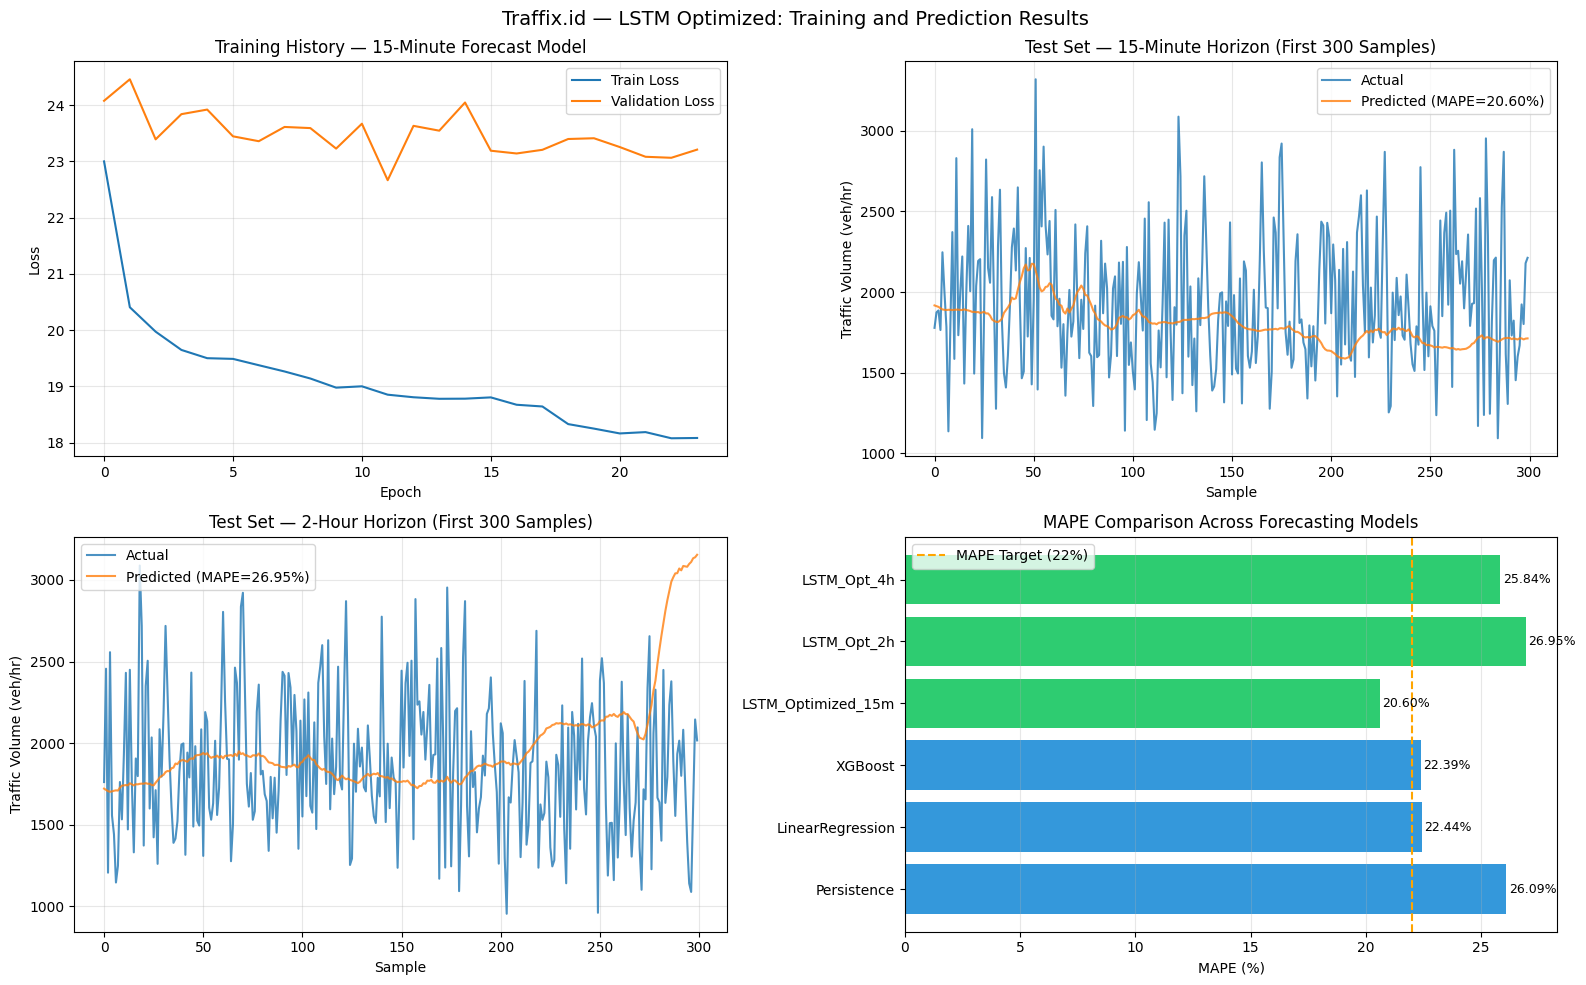

Visualization saved: artifacts/comparison_plot.png


In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Traffix.id — LSTM Optimized: Training and Prediction Results', fontsize=14)

# Panel 1: Training history 15m
ax = axes[0, 0]
if best_history_15m:
    ax.plot(best_history_15m.history['loss'], label='Train Loss')
    ax.plot(best_history_15m.history['val_loss'], label='Validation Loss')
    ax.set_title('Training History — 15-Minute Forecast Model')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(alpha=0.3)

# Panel 2: Prediction vs Actual 15m
ax = axes[0, 1]
n_plot = min(300, len(y_test_true_15m))

ax.plot(
    y_test_true_15m[:n_plot],
    label='Actual',
    alpha=0.8
)

ax.plot(
    y_test_pred_15m[:n_plot],
    label=f'Predicted (MAPE={metrics_15m_opt["MAPE"]:.2f}%)',
    alpha=0.8
)

ax.set_title('Test Set — 15-Minute Horizon (First 300 Samples)')
ax.set_xlabel('Sample')
ax.set_ylabel('Traffic Volume (veh/hr)')
ax.legend()
ax.grid(alpha=0.3)

# Panel 3: Prediction vs Actual 2h
ax = axes[1, 0]
n_plot_2 = min(300, len(y_test_true_2h))

ax.plot(
    y_test_true_2h[:n_plot_2],
    label='Actual',
    alpha=0.8
)

ax.plot(
    y_test_pred_2h[:n_plot_2],
    label=f'Predicted (MAPE={metrics_2h_opt["MAPE"]:.2f}%)',
    alpha=0.8
)

ax.set_title('Test Set — 2-Hour Horizon (First 300 Samples)')
ax.set_xlabel('Sample')
ax.set_ylabel('Traffic Volume (veh/hr)')
ax.legend()
ax.grid(alpha=0.3)

# Panel 4: MAPE Comparison
ax = axes[1, 1]

compare_labels = [
    m['label'] for m in all_metrics
    if m.get('MAPE') is not None
]

compare_mapes = [
    m['MAPE'] for m in all_metrics
    if m.get('MAPE') is not None
]

colors = [
    '#2ecc71' if 'LSTM' in label else '#3498db'
    for label in compare_labels
]

bars = ax.barh(compare_labels, compare_mapes, color=colors)

ax.axvline(
    22.0,
    color='orange',
    linestyle='--',
    label='MAPE Target (22%)'
)

ax.set_xlabel('MAPE (%)')
ax.set_title('MAPE Comparison Across Forecasting Models')
ax.legend()
ax.grid(alpha=0.3, axis='x')

for bar, val in zip(bars, compare_mapes):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        va='center',
        fontsize=9
    )

plt.tight_layout()

viz_path = os.path.join(ARTIFACTS_DIR, 'comparison_plot.png')

plt.savefig(
    viz_path,
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print(f'Visualization saved: {viz_path}')

## 18. Save Artifacts


In [27]:
# 1. Model 15m
path_15m = os.path.join(ARTIFACTS_DIR, 'best_lstm_15m.keras')
best_model_15m.save(path_15m)
print(f'Saved: {path_15m}')

# Model 2h dan 4h sudah disimpan via ModelCheckpoint di train_horizon_model()
print(f'Saved: {os.path.join(ARTIFACTS_DIR, "best_lstm_2h.keras")}')
print(f'Saved: {os.path.join(ARTIFACTS_DIR, "best_lstm_4h.keras")}')

# 2. Feature scaler
feat_sc_path = os.path.join(ARTIFACTS_DIR, 'feat_scaler.joblib')
joblib.dump(feat_scaler, feat_sc_path)
print(f'Saved: {feat_sc_path}')

# 3. Target scalers (dict per horizon)
target_scalers = {
    '15m': best_tgt_scaler_15m,
    '2h' : tgt_sc_2h,
    '4h' : tgt_sc_4h,
}
tgt_sc_path = os.path.join(ARTIFACTS_DIR, 'target_scalers.joblib')
joblib.dump(target_scalers, tgt_sc_path)
print(f'Saved: {tgt_sc_path}')

# 4. Best config
seq_len_b, scaler_b, lr_b, batch_b, dropout_b, loss_b, arch_b = best_cfg_15m
best_config = {
    'horizon'        : '15m',
    'seq_len'        : seq_len_b,
    'target_scaler'  : scaler_b,
    'feature_scaler' : 'standard',
    'learning_rate'  : lr_b,
    'batch_size'     : batch_b,
    'dropout'        : dropout_b,
    'loss'           : loss_b,
    'arch'           : arch_b,
    'val_mape_15m'   : round(best_val_mape_15m, 4),
    'test_mape_15m'  : metrics_15m_opt['MAPE'],
}
cfg_path = os.path.join(ARTIFACTS_DIR, 'best_config.json')
with open(cfg_path, 'w') as f:
    json.dump(best_config, f, indent=2)
print(f'Saved: {cfg_path}')

# 5. Metrics
metrics_all = {
    '15m_optimized': metrics_15m_opt,
    '2h_optimized' : metrics_2h_opt,
    '4h_optimized' : metrics_4h_opt,
    'persistence'  : metrics_persist,
    'linear_reg'   : metrics_linreg,
    'xgboost'      : metrics_xgb,
}
metrics_path = os.path.join(ARTIFACTS_DIR, 'metrics.json')
with open(metrics_path, 'w') as f:
    json.dump(metrics_all, f, indent=2)
print(f'Saved: {metrics_path}')

# 6. Comparison CSV
cmp_path = os.path.join(ARTIFACTS_DIR, 'comparison_results.csv')
df_compare.to_csv(cmp_path, index=False)
print(f'Saved: {cmp_path}')

# 7. Training history CSV
if best_history_15m:
    df_hist = pd.DataFrame(best_history_15m.history)
    df_hist.insert(0, 'epoch', range(1, len(df_hist)+1))
    hist_path = os.path.join(ARTIFACTS_DIR, 'training_history.csv')
    df_hist.to_csv(hist_path, index=False)
    print(f'Saved: {hist_path}')

# 8. Grid results CSV
grid_path = os.path.join(ARTIFACTS_DIR, 'grid_search_results.csv')
df_grid.to_csv(grid_path, index=False)
print(f'Saved: {grid_path}')

print('\nAll artifacts saved successfully.')

Saved: artifacts/best_lstm_15m.keras
Saved: artifacts/best_lstm_2h.keras
Saved: artifacts/best_lstm_4h.keras
Saved: artifacts/feat_scaler.joblib
Saved: artifacts/target_scalers.joblib
Saved: artifacts/best_config.json
Saved: artifacts/metrics.json
Saved: artifacts/comparison_results.csv
Saved: artifacts/training_history.csv
Saved: artifacts/grid_search_results.csv

All artifacts saved successfully.


## 19. Export ZIP Archive


In [28]:
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(ARTIFACTS_DIR):
        for file in files:
            fp = os.path.join(root, file)
            arcname = os.path.relpath(fp, '.')
            zf.write(fp, arcname)
            print(f'  Added: {arcname}')

print(f'\nZIP created: {ZIP_PATH}')

# Auto-download di Colab
try:
    from google.colab import files
    files.download(ZIP_PATH)
    print('Artifact archive download initiated.')
except ImportError:
    print(f'[INFO] Not running in Google Colab. Retrieve the archive manually: {ZIP_PATH}')

  Added: artifacts/best_config.json
  Added: artifacts/metrics.json
  Added: artifacts/comparison_plot.png
  Added: artifacts/_tmp_best.keras
  Added: artifacts/comparison_results.csv
  Added: artifacts/grid_search_results.csv
  Added: artifacts/best_lstm_4h.keras
  Added: artifacts/training_history.csv
  Added: artifacts/target_scalers.joblib
  Added: artifacts/feat_scaler.joblib
  Added: artifacts/best_lstm_15m.keras
  Added: artifacts/best_lstm_2h.keras

ZIP created: traffix_lstm_optimized_artifacts.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Artifact archive download initiated.


## 20. Final Summary


In [29]:
print('\n' + '='*70)
print('Traffix.id — LSTM Optimization Summary')
print('='*70)

print(f'\nOptimal Configuration (15-minute horizon):')
for k, v in best_config.items():
    print(f'  {k:<20}: {v}')

print(f'\n--- MAPE by Horizon ---')
print(f'  Prior LSTM (15-minute)      : 24.665%')
print(f'  LSTM Optimized (15-minute)  : {metrics_15m_opt["MAPE"]:.3f}%')
print(f'  LSTM Optimized (2-hour)     : {metrics_2h_opt["MAPE"]:.3f}%')
print(f'  LSTM Optimized (4-hour)     : {metrics_4h_opt["MAPE"]:.3f}%')

print(f'\n--- Baseline Comparison (15-minute target) ---')
print(f'  Persistence        : {metrics_persist["MAPE"]:.3f}%')
print(f'  Linear Regression  : {metrics_linreg["MAPE"]:.3f}%')
if metrics_xgb.get('MAPE'):
    print(f'  XGBoost            : {metrics_xgb["MAPE"]:.3f}%')
print(f'  LSTM Optimized     : {metrics_15m_opt["MAPE"]:.3f}%')

print(f'\n--- Exported Artifacts ---')
for f in os.listdir(ARTIFACTS_DIR):
    fp = os.path.join(ARTIFACTS_DIR, f)
    sz = os.path.getsize(fp) / 1024
    print(f'  {f:<40} {sz:>8.1f} KB')

print('\n' + '='*70)
print('Artifacts exported to artifacts/ and packaged in ZIP archive.')
print('='*70)


Traffix.id — LSTM Optimization Summary

Optimal Configuration (15-minute horizon):
  horizon             : 15m
  seq_len             : 60
  target_scaler       : robust
  feature_scaler      : standard
  learning_rate       : 0.0005
  batch_size          : 32
  dropout             : 0.1
  loss                : mape_safe
  arch                : lstm_light
  val_mape_15m        : 19.9826
  test_mape_15m       : 20.6046

--- MAPE by Horizon ---
  Prior LSTM (15-minute)      : 24.665%
  LSTM Optimized (15-minute)  : 20.605%
  LSTM Optimized (2-hour)     : 26.953%
  LSTM Optimized (4-hour)     : 25.837%

--- Baseline Comparison (15-minute target) ---
  Persistence        : 26.094%
  Linear Regression  : 22.445%
  XGBoost            : 22.387%
  LSTM Optimized     : 20.605%

--- Exported Artifacts ---
  best_config.json                              0.3 KB
  metrics.json                                  1.4 KB
  comparison_plot.png                         478.7 KB
  _tmp_best.keras           